Processed data is stored in pkl file<br>
Load data and fit with PyMC<br>
Pt100 KOH CO oxidation<br>

**Models:**<br> 

ER:<br> 
1. CO + * -> CO*<br> 
2. CO* + OH- -> COOH* + e-<br> 
3. COOH* + OH- -> CO2 + H2O + * + e-<br>
4. OH- + * -> OH* + e-<br>

LH: <br>
1. CO + * -> CO*<br>
2. CO* + OH* -> COOH* + *<br> 
3. COOH* + OH- -> CO2 + H2O + * + e-<br>
4. OH- + * -> OH* + e-<br>

Updates: 
1. ER_3 eliminated for bad fits. 
2. LH_3 eliminated for bad fits. 
3. LH_2 eliminated for bad fits. 
4. ER_2 looks good. 
5. ER_2_3: KO rhat
6. ER_LH_2: KO divergences
7. ER_LH_2_3: KO rhat (+ divergences rate)

# Initialization - KO only 

In [1]:
import numpy as np
import pymc as pm
import arviz as az
import pandas as pd
import xarray as xr
import pickle 
import nutpie
import matplotlib.pyplot as plt
import pytensor.tensor as pt
import itertools

plt.rcParams['figure.dpi'] = 60
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

# Experimental conditions and constants 
C_KOH_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm
conditions = list(itertools.product(C_KOH_list, P_CO_list))
R, T, F = 8.3145, 298.15, 96485
kb_eV, h, kb_J = 8.617e-5, 6.626e-34, 1.3806e-23  # eV/K, J.s, J/K 

# Load and parse data
with open('Pt100_KOH_replicates.pkl', 'rb') as f:
    experiments_interp = pickle.load(f)
E_obs = experiments_interp[(0.1, 0.1)]['E'] # V vs SHE - random conditions

alpha_obs = np.zeros((len(C_KOH_list), len(P_CO_list), len(E_obs)))
alpha_obs_SD = np.zeros((len(C_KOH_list), len(P_CO_list), len(E_obs)))
for i, C_KOH in enumerate(C_KOH_list):
    for j, P_CO in enumerate(P_CO_list):
        alpha_obs[i, j, :] = experiments_interp[(C_KOH, P_CO)]['alpha']
        alpha_obs_SD[i, j, :] = experiments_interp[(C_KOH, P_CO)]['alpha_SD']

delta_OH_obs = np.zeros((len(P_CO_list), len(E_obs)))
delta_OH_obs_SD = np.zeros((len(P_CO_list), len(E_obs)))
for j, P_CO in enumerate(P_CO_list):
    delta_OH_obs[j, :] = experiments_interp[(0.1, P_CO)]['delta_OH'] # Random C_KOH
    delta_OH_obs_SD[j, :] = experiments_interp[(0.1, P_CO)]['delta_OH_SD']

delta_CO_obs = np.zeros((len(C_KOH_list), len(P_CO_list)-1, len(E_obs)))
delta_CO_obs_SD = np.zeros((len(C_KOH_list), len(P_CO_list)-1, len(E_obs)))
for i, C_KOH in enumerate(C_KOH_list):
    for j, P_CO in enumerate(P_CO_list[:-1]): 
        delta_CO_obs[i, j, :] = experiments_interp[(C_KOH, P_CO)]['delta_CO']
        delta_CO_obs_SD[i, j, :] = experiments_interp[(C_KOH, P_CO)]['delta_CO_SD']

# Constructing variables to make it more feasible for models
# Variables reshaped for broadcasting
dE = E_obs[1] - E_obs[0]
d_ln_P_CO = np.diff(np.log(P_CO_list))[None, :, None]

# Need this because np.polyfit doesn't work with pymc variables - used for delta_OH
ln_C = np.log(C_KOH_list)
ln_C_mean = np.mean(ln_C)
S_xx = np.sum((ln_C - ln_C_mean)**2)
w_C = (ln_C - ln_C_mean) / S_xx
w_C_in = w_C[:, None, None]

C_KOH_in = C_KOH_list[:, None, None] # Shape (N, 1, 1)
P_CO_in = P_CO_list[None, :, None] # Shape (1, N, 1)
E_in = E_obs[None, None, :] # Shape (1, 1, N)

def calc_observables(log_rate): 
    '''
    Converts a raw rate tensor (C_KOH, P_CO, E) into kinetic observables (alpha, delta_OH, delta_CO).
    Returns PyTensor variables ready for the model.
    '''
    # Alpha with central difference (forward/backward difference at edges - no points lost)
    d_log_rate_dE = pt.zeros_like(log_rate)
    d_log_rate_center_dE = (log_rate[:, :, 2:] - log_rate[:, :, :-2]) / (2*dE)
    d_log_rate_dE = pt.set_subtensor(d_log_rate_dE[:, :, 1:-1], d_log_rate_center_dE)
    d_log_rate_start_dE = (log_rate[:, :, 1] - log_rate[:, :, 0]) / dE
    d_log_rate_dE = pt.set_subtensor(d_log_rate_dE[:, :, 0], d_log_rate_start_dE)
    d_log_rate_end_dE = (log_rate[:, :, -1] - log_rate[:, :, -2]) / dE
    d_log_rate_dE = pt.set_subtensor(d_log_rate_dE[:, :, -1], d_log_rate_end_dE)
    mu_alpha = (R*T/F) * d_log_rate_dE

    # Delta OH with linear regression: weights set up earlier
    mu_delta_OH = pm.math.sum(w_C_in * log_rate, axis=0)

    # Delta CO with finite difference, losing a P_CO point
    d_log_rate_P = log_rate[:, 1:, :] - log_rate[:, :-1, :]
    mu_delta_CO = d_log_rate_P / d_ln_P_CO

    return mu_alpha, mu_delta_OH, mu_delta_CO

def get_combined_loo(idata):
    """
    Merges multiple log-likelihood variables into a single array 
    and calculates the global LOO score, preserving the posterior for Reff.
    """
    ll_list = []
    for var_name in idata.log_likelihood.data_vars:
        da = idata.log_likelihood[var_name]
        obs_dims = [d for d in da.dims if d not in ('chain', 'draw')]
        if obs_dims: da_flat = da.stack(observations=obs_dims)
        else: da_flat = da.expand_dims(observations=1) 
        da_flat = da_flat.reset_index('observations', drop=True)
        ll_list.append(da_flat)

    combined_ll = xr.concat(ll_list, dim='observations')
    combined_ll = combined_ll.assign_coords(observations=range(combined_ll.sizes['observations']))
    new_idata = az.InferenceData(posterior=idata.posterior, log_likelihood=combined_ll.to_dataset(name='total_model')) 
    return az.loo(new_idata, var_name='total_model', pointwise=True)

def calculate_flattened_r2(ppc, var_name):
    y_true = ppc.observed_data[var_name].values
    y_pred = ppc.posterior_predictive[var_name].values
    y_true_flat = y_true.flatten()
    chains, draws = y_pred.shape[:2]
    y_pred_flat = y_pred.reshape(chains * draws, -1)
    r2 = az.r2_score(y_true_flat, y_pred_flat)
    return r2['r2']

def plot_posteriors(trace, model, figsize=(14,5)): 
    
    all_vars = list(trace.posterior.data_vars)
    var_names = [v for v in all_vars if not v.endswith("__")]
    kinetic_vars = [v for v in var_names if not v.startswith('theta')]
    print(f"Kinetic Parameters found: {kinetic_vars}")
    summary = az.summary(trace, var_names=kinetic_vars)
    print(summary)

    if kinetic_vars:
        az.plot_posterior(trace, var_names=kinetic_vars, hdi_prob=0.95, round_to=3, figsize=figsize)
        plt.suptitle("Kinetic Parameters (Physics)", y=1.05, fontsize=16, fontweight='bold')
        plt.show()

    if len(kinetic_vars) > 1:
        az.plot_pair(trace, var_names=kinetic_vars, kind='kde', divergences=True, figsize=(10, 9))
        plt.suptitle("Parameter Correlations", y=1.02, fontsize=16, fontweight='bold')
        plt.show()

    with model: ppc = pm.sample_posterior_predictive(trace, progressbar=False)

    for var_name in ppc.observed_data.data_vars:
        r2 = calculate_flattened_r2(ppc, var_name)
        print(f"{var_name}: {r2:.3f}")
        
    return ppc

def plot_model_fits(ppc):
    
    colors = plt.cm.tab10.colors[:len(P_CO_list)]

    # --- 1. Transfer Coefficients (Alpha) - 4x4 Grid ---
    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 14), sharex=True, sharey=True)
    fig.suptitle('Transfer Coefficients (Model vs Exp)', fontsize=20, fontweight='bold', y=0.98)

    for i, C_KOH in enumerate(C_KOH_list):
        for j, P_CO in enumerate(P_CO_list):

            ax = axes[j, i]
            E_exp = experiments_interp[(C_KOH, P_CO)]['E']
            alpha_exp = experiments_interp[(C_KOH, P_CO)]['alpha']
            model_data = ppc.posterior_predictive['alpha'][:, :, i, j, :]
            model_mean = model_data.mean(dim=("chain", "draw"))
            hdi_95 = az.hdi(model_data, hdi_prob=0.95)[model_data.name]
            hdi_90 = az.hdi(model_data, hdi_prob=0.90)[model_data.name]
            
            ax.fill_between(E_exp, hdi_95[:, 0].values, hdi_95[:, 1].values, color=colors[j], alpha=0.15, linewidth=0, label='95% HDI')
            ax.fill_between(E_exp, hdi_90[:, 0].values, hdi_90[:, 1].values, color=colors[j], alpha=0.35, linewidth=0, label='90% HDI')
            ax.plot(E_exp, model_mean, color=colors[j], lw=2)
            ax.scatter(E_exp, alpha_exp, color='k', s=10, marker='o', edgecolors='white', linewidth=0.25)

            if j == 0: ax.set_title(f'{C_KOH} M KOH', fontsize=14, fontweight='bold')
            if i == 3: ax.text(1.05, 0.5, f'{P_CO} atm', transform=ax.transAxes, rotation=-90, va='center', fontsize=14, fontweight='bold')
            if j == 3: ax.set_xlabel("E vs SHE (V)")
            if i == 0: ax.set_ylabel("alpha")

    plt.tight_layout()
    plt.subplots_adjust(right=0.95) 
    plt.show()

    # --- 2. OH Reaction Order (Delta OH) - 1x4 Grid ---
    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4.5), sharex=True, sharey=True)
    fig.suptitle('OH Reaction Order', fontsize=20, fontweight='bold', y=1.05)

    for j, P_CO in enumerate(P_CO_list):

        ax = axes[j]
        delta_OH_exp = experiments_interp[(0.1, P_CO)]['delta_OH']
        E_exp = experiments_interp[(0.1, P_CO)]['E']
        model_data = ppc.posterior_predictive['delta_OH'][:, :, j, :]
        model_mean = model_data.mean(dim=("chain", "draw"))
        hdi_95 = az.hdi(model_data, hdi_prob=0.95)[model_data.name]
        hdi_90 = az.hdi(model_data, hdi_prob=0.90)[model_data.name]

        ax.fill_between(E_exp, hdi_95[:, 0].values, hdi_95[:, 1].values, color=colors[j], alpha=0.15, linewidth=0)
        ax.fill_between(E_exp, hdi_90[:, 0].values, hdi_90[:, 1].values, color=colors[j], alpha=0.35, linewidth=0)
        ax.plot(E_exp, model_mean, color=colors[j], lw=2)
        ax.scatter(E_exp, delta_OH_exp, color='k', s=10, marker='o', edgecolors='white', linewidth=0.25)

        ax.set_title(f'{P_CO} atm', fontsize=14)
        ax.set_xlabel("E vs SHE (V)")
        if j == 0: ax.set_ylabel("Reaction Order (OH)")

    plt.tight_layout()
    plt.show()

    # --- 3. CO Reaction Order (Delta CO) - 3x4 Grid ---
    fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12), sharex=True, sharey=True)
    fig.suptitle('CO Reaction Order', fontsize=20, fontweight='bold', y=0.98)
    for j in range(len(P_CO_list) - 1):
        P_CO_start = P_CO_list[j]
        P_CO_end = P_CO_list[j+1]
        for i, C_KOH in enumerate(C_KOH_list):
           
            ax = axes[j, i]
            delta_CO_exp = experiments_interp[(C_KOH, P_CO_start)]['delta_CO']
            E_exp = experiments_interp[(C_KOH, P_CO_start)]['E']
            model_data = ppc.posterior_predictive['delta_CO'][:, :, i, j, :]
            model_mean = model_data.mean(dim=("chain", "draw"))
            hdi_95 = az.hdi(model_data, hdi_prob=0.95)[model_data.name]
            hdi_90 = az.hdi(model_data, hdi_prob=0.90)[model_data.name]

            ax.fill_between(E_exp, hdi_95[:, 0].values, hdi_95[:, 1].values, color=colors[j], alpha=0.15, linewidth=0)
            ax.fill_between(E_exp, hdi_90[:, 0].values, hdi_90[:, 1].values, color=colors[j], alpha=0.35, linewidth=0)
            ax.plot(E_exp, model_mean, color=colors[j], lw=2)
            ax.scatter(E_exp, delta_CO_exp, color='k', s=10, marker='o', edgecolors='white', linewidth=0.25)

            if j == 0: ax.set_title(f'{C_KOH} M KOH', fontsize=14, fontweight='bold')   
            if i == 3: label_text = f'{P_CO_start}-{P_CO_end} atm'; ax.text(1.05, 0.5, label_text, transform=ax.transAxes, rotation=-90, va='center', fontsize=12, fontweight='bold')
            if j == 2: ax.set_xlabel("E vs SHE (V)")
            if i == 0: ax.set_ylabel("Reaction Order (CO)")

    plt.tight_layout()
    plt.subplots_adjust(right=0.95)
    plt.show()

def plot_coverages(trace):

    # Shape of theta in trace: (Chain, Draw, N_C_KOH, N_P_CO, N_E)
    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 14), sharex=True, sharey=True)
    fig.suptitle('Modeled Surface Coverages', fontsize=20, fontweight='bold', y=0.98)

    # Loop over C_KOH (Columns) and P_CO (Rows)
    for i, C_KOH in enumerate(C_KOH_list):
        for j, P_CO in enumerate(P_CO_list):
            ax = axes[j, i]
            E_exp = experiments_interp[(C_KOH, P_CO)]['E']

            # Slicing: [All Chains, All Draws, i, j, All E]
            theta_CO_data = trace.posterior['theta_CO'][:, :, i, j, :]
            theta_OH_data = trace.posterior['theta_OH'][:, :, i, j, :]
            mu_CO = theta_CO_data.mean(dim=("chain", "draw"))
            mu_OH = theta_OH_data.mean(dim=("chain", "draw"))
            hdi_CO_95 = az.hdi(theta_CO_data, hdi_prob=0.95)['theta_CO']
            hdi_CO_90 = az.hdi(theta_CO_data, hdi_prob=0.90)['theta_CO']
            hdi_OH_95 = az.hdi(theta_OH_data, hdi_prob=0.95)['theta_OH']
            hdi_OH_90 = az.hdi(theta_OH_data, hdi_prob=0.90)['theta_OH']

            ax.fill_between(E_exp, hdi_CO_95[:, 0], hdi_CO_95[:, 1], color='tab:red', alpha=0.15, linewidth=0)
            ax.fill_between(E_exp, hdi_CO_90[:, 0], hdi_CO_90[:, 1], color='tab:red', alpha=0.35, linewidth=0)
            ax.plot(E_exp, mu_CO, color='tab:red', label=r'$\theta_{CO}$', lw=2)

            ax.fill_between(E_exp, hdi_OH_95[:, 0], hdi_OH_95[:, 1], color='tab:blue', alpha=0.15, linewidth=0)
            ax.fill_between(E_exp, hdi_OH_90[:, 0], hdi_OH_90[:, 1],  color='tab:blue', alpha=0.35, linewidth=0)
            ax.plot(E_exp, mu_OH, color='tab:blue', label=r'$\theta_{OH}$', lw=2)

            ax.set_ylim(-0.05, 1.05)
            if j == 0: ax.set_title(f'{C_KOH} M KOH', fontsize=14, fontweight='bold')
            if i == 3: ax.text(1.05, 0.5, f'{P_CO} atm', transform=ax.transAxes, rotation=-90, va='center', fontsize=14, fontweight='bold')
            if j == 3: ax.set_xlabel("E vs SHE (V)")
            if i == 0: ax.set_ylabel("Coverage")  
            if i == 0 and j == 0: ax.legend(loc='center left', frameon=False)

    plt.tight_layout()
    plt.subplots_adjust(right=0.95)
    plt.show()

In [ ]:
def fit_and_evaluate(model, draws=1000, tune=1000, chains=4, cores=2, init_mean=None, target_accept=0.95):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = get_combined_loo(trace)
    print(loo)
    az.plot_khat(loo)
    plt.title("Pareto k diagnostic (Global Model)"); plt.show()
    return trace, loo

def observables(log_rate): 
    mu_alpha, mu_delta_OH, mu_delta_CO = calc_observables(log_rate)
    alpha = pm.StudentT('alpha', nu=3, mu=mu_alpha, sigma=alpha_obs_SD, observed=alpha_obs)
    delta_OH = pm.StudentT('delta_OH', nu=3, mu=mu_delta_OH, sigma=delta_OH_obs_SD, observed=delta_OH_obs)
    delta_CO = pm.StudentT('delta_CO', nu=3, mu=mu_delta_CO, sigma=delta_CO_obs_SD, observed=delta_CO_obs)
    return alpha, delta_OH, delta_CO

# LH 2

# ER 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.51,3
,2000,0,0.56,7
,2000,0,0.54,7
,2000,0,0.56,7


Computed from 4000 posterior samples and 6400 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -5573.73   214.69
p_loo       18.71        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     6400  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



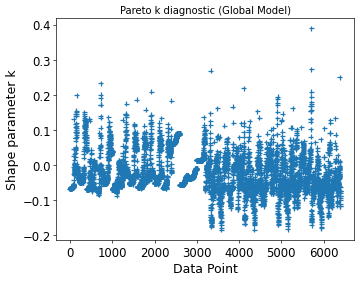

In [3]:
# Eley-Rideal Model - 2nd step is RDS  
with pm.Model() as ER_2:
    '''
    1. CO + * -> CO* 
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) 
    4. OH- + * -> OH* + (e-)
    '''
    # Priors
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-0.5, upper=0.1) 
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-0.4, upper=0.2) # at 0V_SHE
    beta_2 = pm.Uniform('beta_2', lower=0.05, upper=0.95)      
    Gact2_0 = 0 # Fixed at 0 eV at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO + term_OH)
    log_theta = - pm.math.logsumexp(pt.stack([zeros, term_CO+zeros, term_OH+zeros]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pm.math.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pm.math.exp(log_theta_OH))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + np.log(C_KOH_in)
    alpha, delta_OH, delta_CO = observables(log_rate)

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

Kinetic Parameters found: ['deltaG1_0', 'deltaG4_0', 'beta_2']
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.136  0.001  -0.138   -0.134        0.0      0.0    2196.0    2513.0    1.0
deltaG4_0 -0.040  0.001  -0.042   -0.038        0.0      0.0    2060.0    2252.0    1.0
beta_2     0.244  0.002   0.240    0.247        0.0      0.0    2589.0    2456.0    1.0


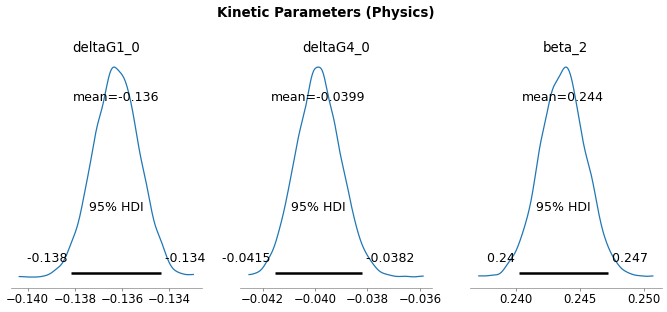

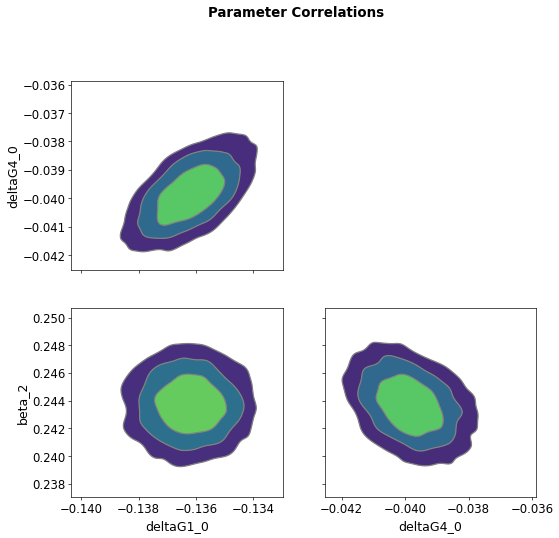

Sampling: [alpha, delta_CO, delta_OH]


alpha: 0.687
delta_OH: 0.560
delta_CO: 0.623


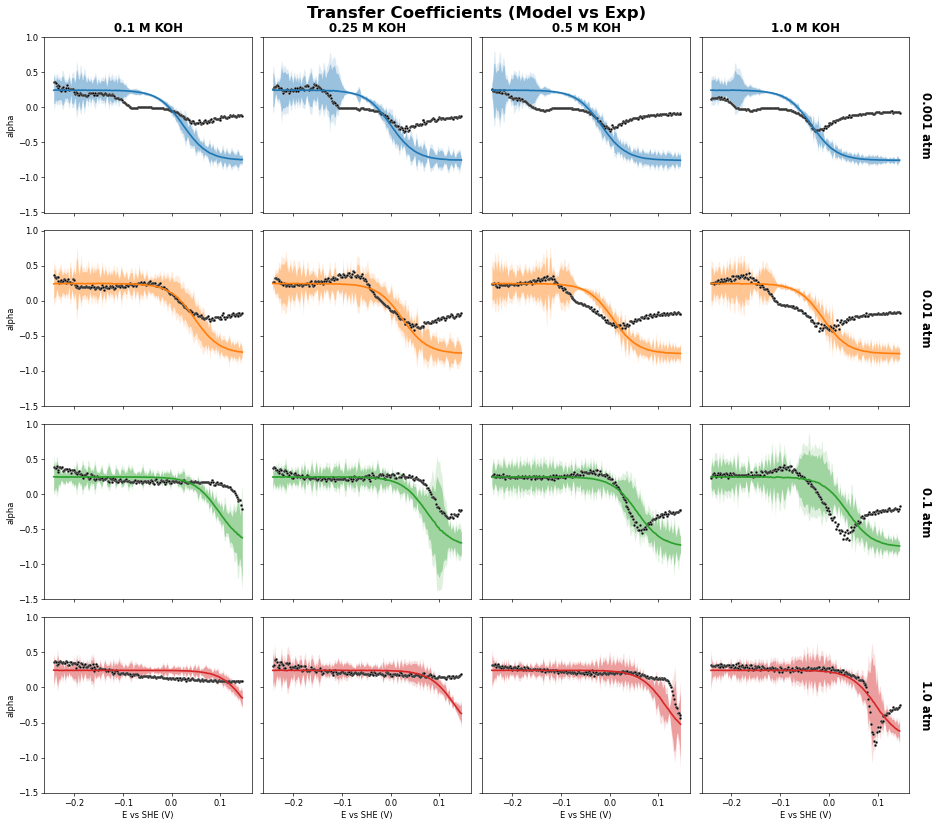

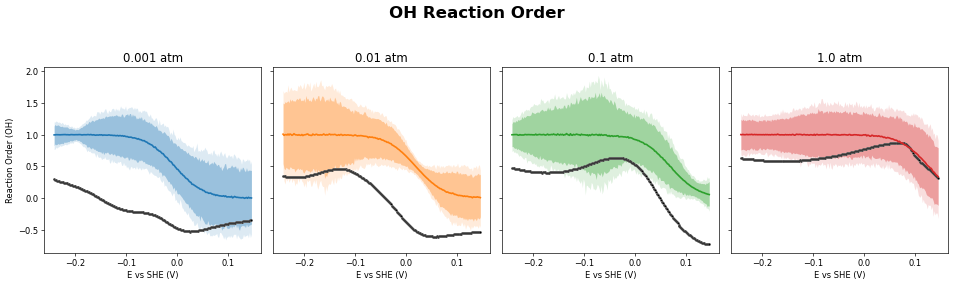

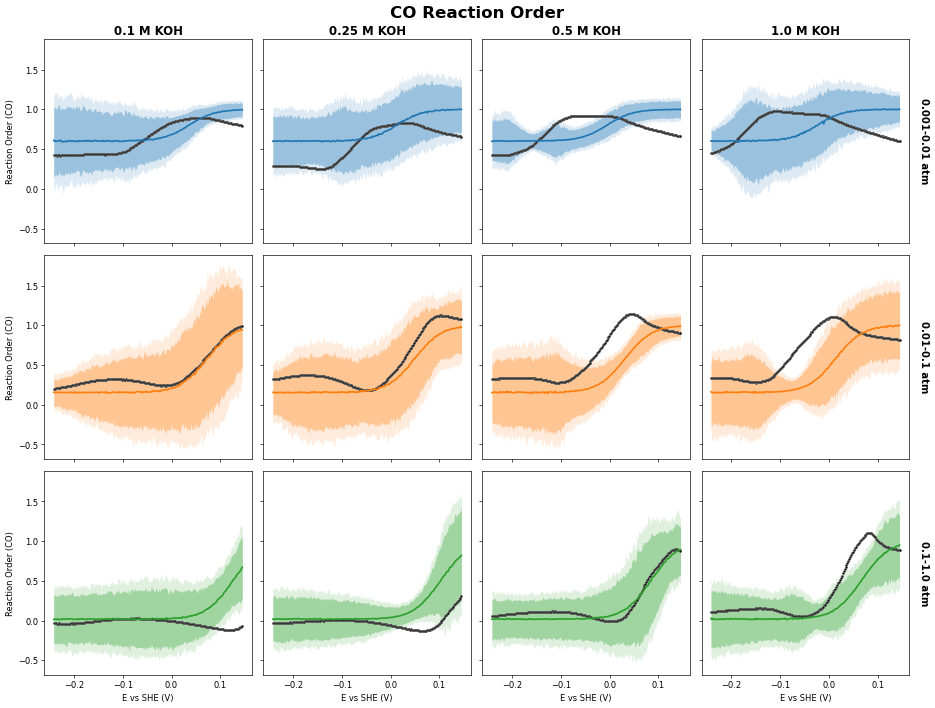

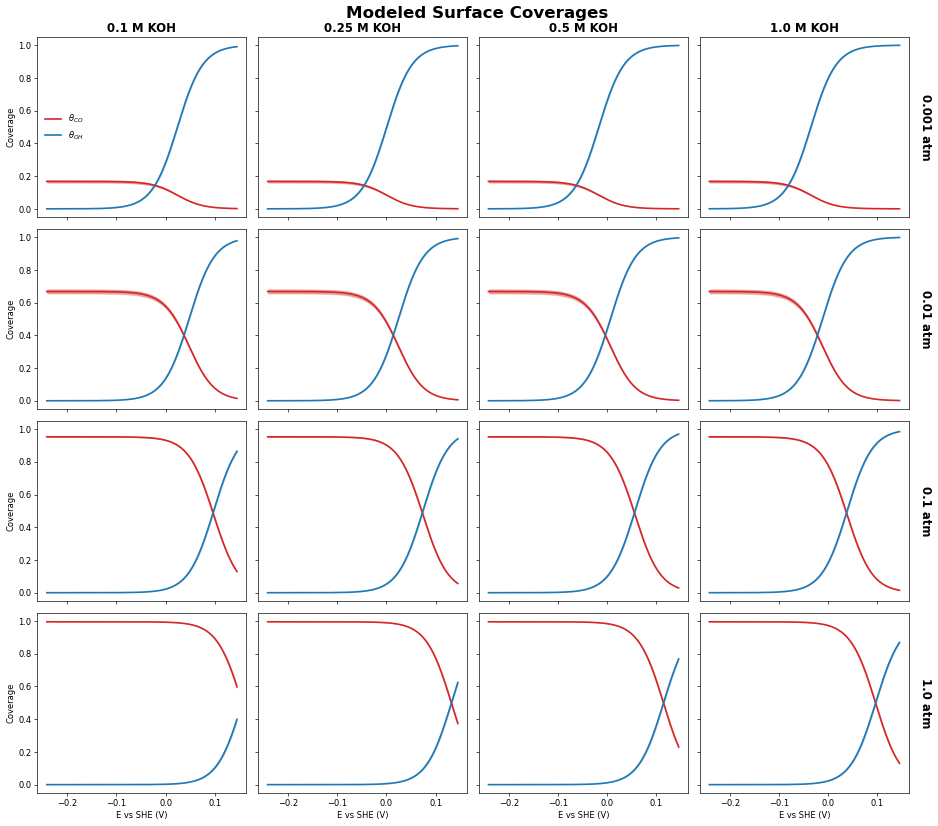

In [4]:
ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2)
plot_model_fits(ppc_ER_2); plot_coverages(trace_ER_2)

# ER 3

# LH 3

# ER 2 3 - Series RDS

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.10,15
,2000,0,0.17,63
,2000,0,0.36,7
,2000,0,0.09,111


Computed from 4000 posterior samples and 6400 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2996.97   164.89
p_loo     3728.34        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     6400  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



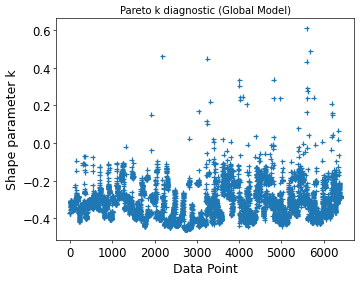

In [9]:
# Eley-Rideal Model - 2nd and 3rd steps are RDS 
with pm.Model() as ER_2_3:
    '''
    1. CO + * -> CO* 
    2. CO* + OH- -> COOH* + (e-) (RDS) (Reversible)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (RDS)
    4. OH- + * -> OH* + (e-)
    '''
    # Priors
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-0.5, upper=0.1) 
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-0.4, upper=0.2) # at 0V_SHE
    deltaG2_0 = pm.Normal('deltaG2_0', mu=0, sigma=0.5) # at 0V_SHE
    beta_2 = pm.Uniform('beta_2', lower=0.05, upper=0.95)
    beta_3 = pm.Uniform('beta_3', lower=0.05, upper=0.95)
    Gact2_0 = 0 # Fixed at 0 eV at 0V_SHE
    Gact3_0 = pm.Normal('Gact3_0', mu=0, sigma=0.5) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG2 = deltaG2_0 - E_in
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    Gact3 = Gact3_0 - beta_3*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K2 = -deltaG2/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    term_COOH = log_k2 + term_CO + np.log(C_KOH_in) - pm.math.logaddexp(log_k2 - log_K2, log_k3 + np.log(C_KOH_in))
    zeros = pt.zeros_like(term_CO + term_OH)
    log_theta = - pm.math.logsumexp(pt.stack([zeros, term_CO+zeros, term_OH+zeros, term_COOH+zeros]), axis=0) 
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pm.math.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pm.math.exp(log_theta_OH))

    # Rate expression
    log_rate = log_k3 + log_theta_COOH + np.log(C_KOH_in)
    alpha, delta_OH, delta_CO = observables(log_rate)

trace_ER_2_3, loo_ER_2_3 = fit_and_evaluate(ER_2_3)

Kinetic Parameters found: ['deltaG2_0', 'Gact3_0', 'deltaG1_0', 'deltaG4_0', 'beta_2', 'beta_3']
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG2_0 -0.451  0.225  -0.914   -0.330      0.089    0.066       5.0      34.0   2.10
Gact3_0    0.167  0.102  -0.005    0.249      0.051    0.027       5.0      34.0   2.10
deltaG1_0 -0.146  0.045  -0.201   -0.076      0.022    0.009       5.0      33.0   2.12
deltaG4_0 -0.228  0.200  -0.395    0.109      0.099    0.053       5.0      28.0   2.12
beta_2     0.617  0.328   0.050    0.838      0.163    0.094       5.0      30.0   2.41
beta_3     0.264  0.035   0.231    0.326      0.017    0.010       5.0      31.0   2.41


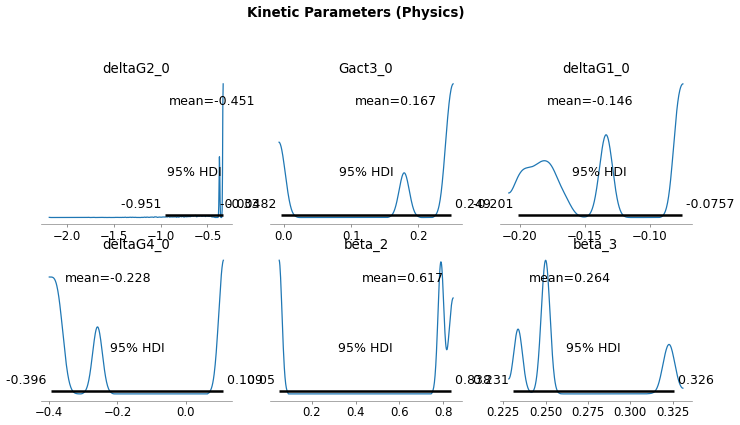

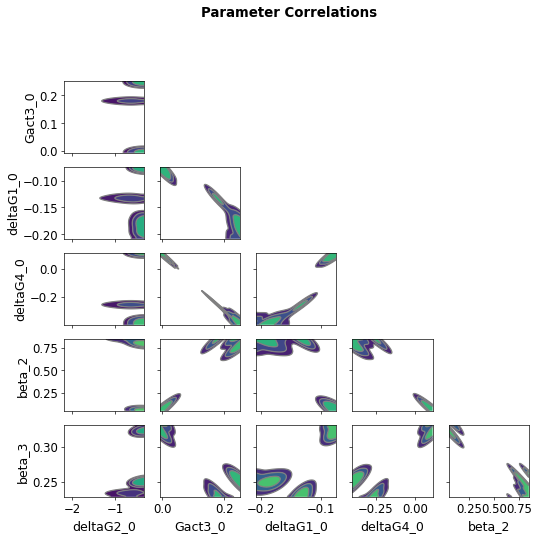

Sampling: [alpha, delta_CO, delta_OH]


alpha: 0.570
delta_OH: 0.542
delta_CO: 0.639


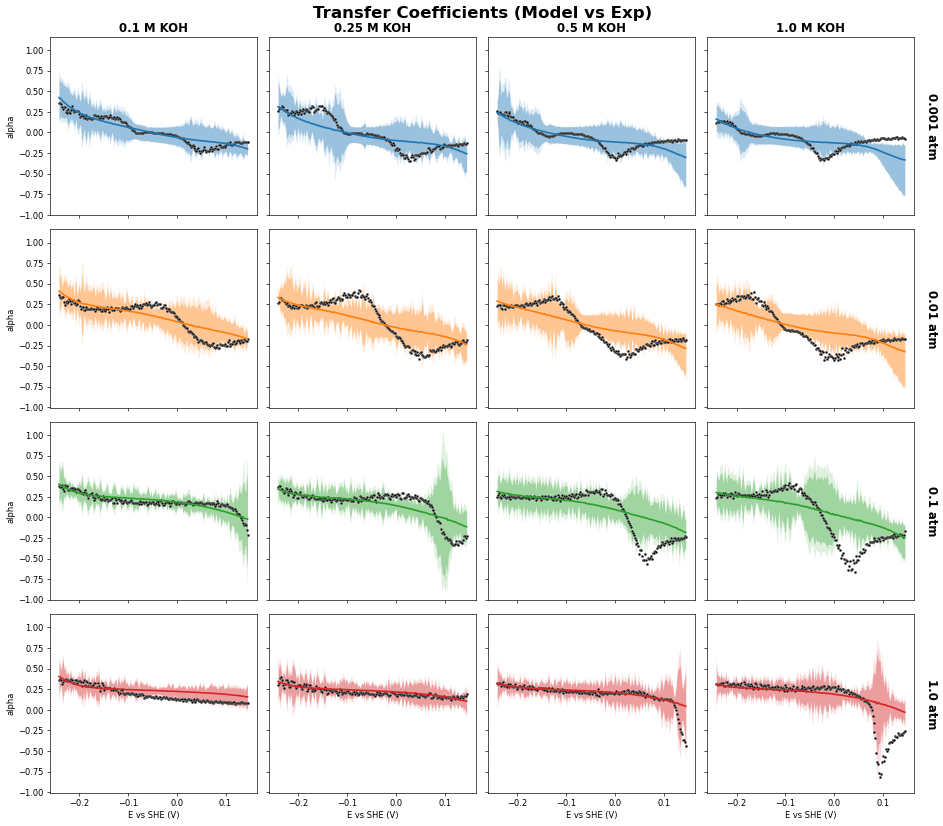

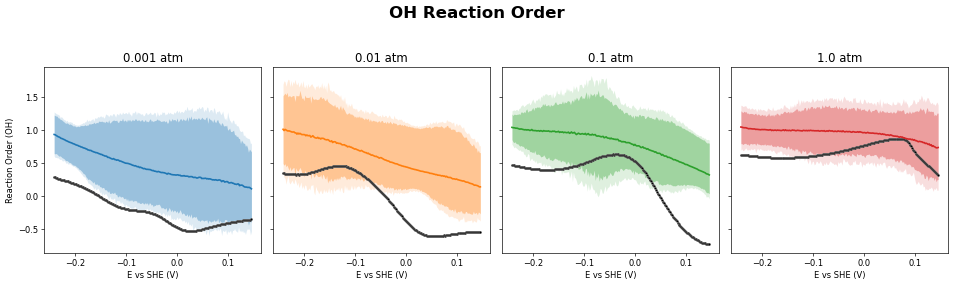

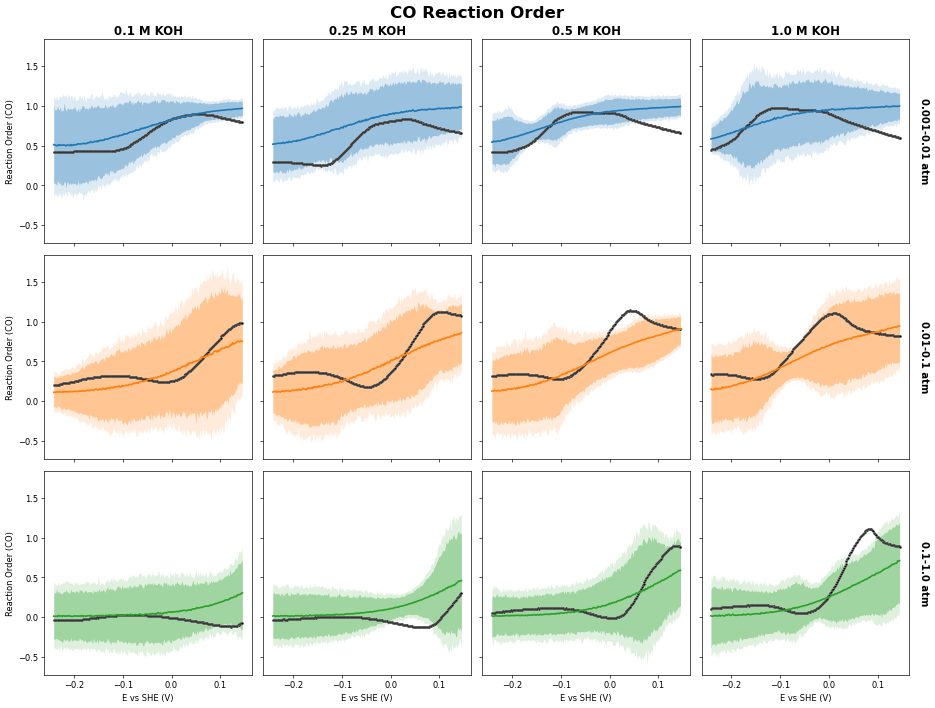

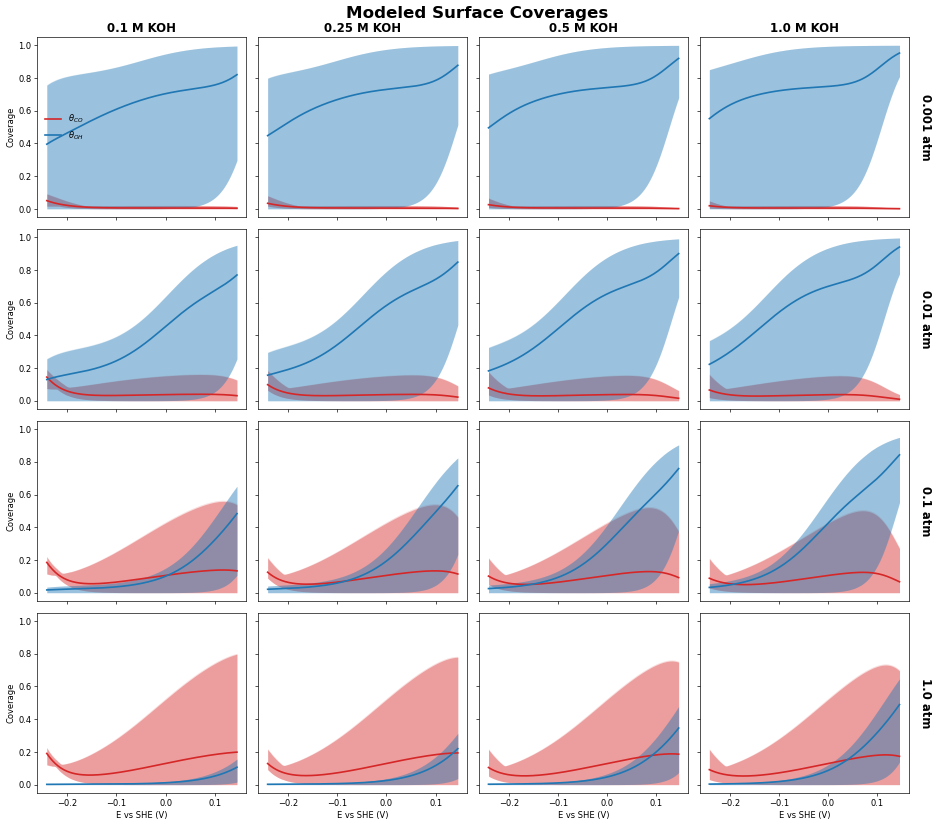

In [10]:
ppc_ER_2_3 = plot_posteriors(trace_ER_2_3, ER_2_3, (14,7))
plot_model_fits(ppc_ER_2_3); plot_coverages(trace_ER_2_3)

# ER 2 + LH 2 - Parallel RDS

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.18,31
,2000,2,0.20,15
,2000,1,0.29,7
,2000,1,0.19,23


Computed from 4000 posterior samples and 6400 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -5573.76   214.69
p_loo       18.69        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     6400  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



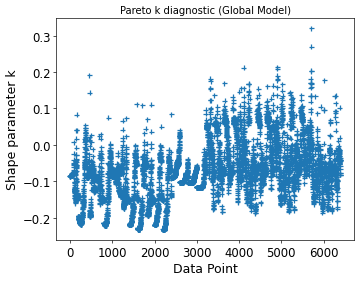

In [11]:
# Eley-Rideal + Langmuir-Hinshelwood Hybrid Model - 2nd step is RDS
with pm.Model() as ER_LH_2:
    '''
    1. CO + * -> CO* 
    2a. CO* + OH- -> COOH* + (e-) (RDS)
    2b. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) 
    4. OH- + * -> OH* + (e-)
    '''
    # Priors
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-0.5, upper=0.1) 
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-0.4, upper=0.2) # at 0V_SHE
    beta_2 = pm.Uniform('beta_2', lower=0.05, upper=0.95)
    Gact2_0_LH = 0 # Fixed at 0 eV
    Gact2_0_ER = pm.Normal('Gact2_0_ER', mu=0, sigma=0.5) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2_LH = Gact2_0_LH
    Gact2_ER = Gact2_0_ER - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO + term_OH)
    log_theta = - pm.math.logsumexp(pt.stack([zeros, term_CO+zeros, term_OH+zeros]), axis=0) 
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pm.math.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pm.math.exp(log_theta_OH))

    # Rate expression
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH
    log_rate = pm.math.logaddexp(log_rate_ER, log_rate_LH)
    alpha, delta_OH, delta_CO = observables(log_rate)

trace_ER_LH_2, loo_ER_LH_2 = fit_and_evaluate(ER_LH_2)

Kinetic Parameters found: ['Gact2_0_ER', 'deltaG1_0', 'deltaG4_0', 'beta_2']
             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
Gact2_0_ER -0.534  0.273  -1.041   -0.169      0.013     0.01     579.0     747.0   1.01
deltaG1_0  -0.136  0.001  -0.138   -0.134      0.000     0.00    1678.0    2107.0   1.00
deltaG4_0  -0.040  0.001  -0.042   -0.038      0.000     0.00    1484.0    1691.0   1.00
beta_2      0.244  0.002   0.240    0.247      0.000     0.00    2396.0    2332.0   1.00


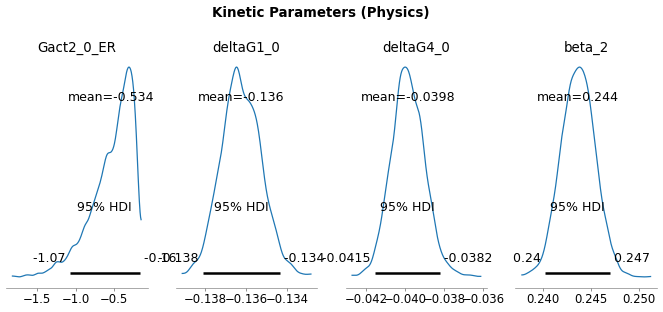

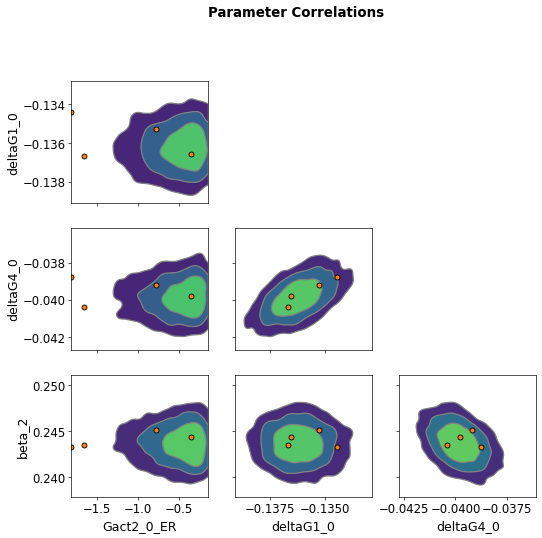

Sampling: [alpha, delta_CO, delta_OH]


alpha: 0.688
delta_OH: 0.560
delta_CO: 0.623


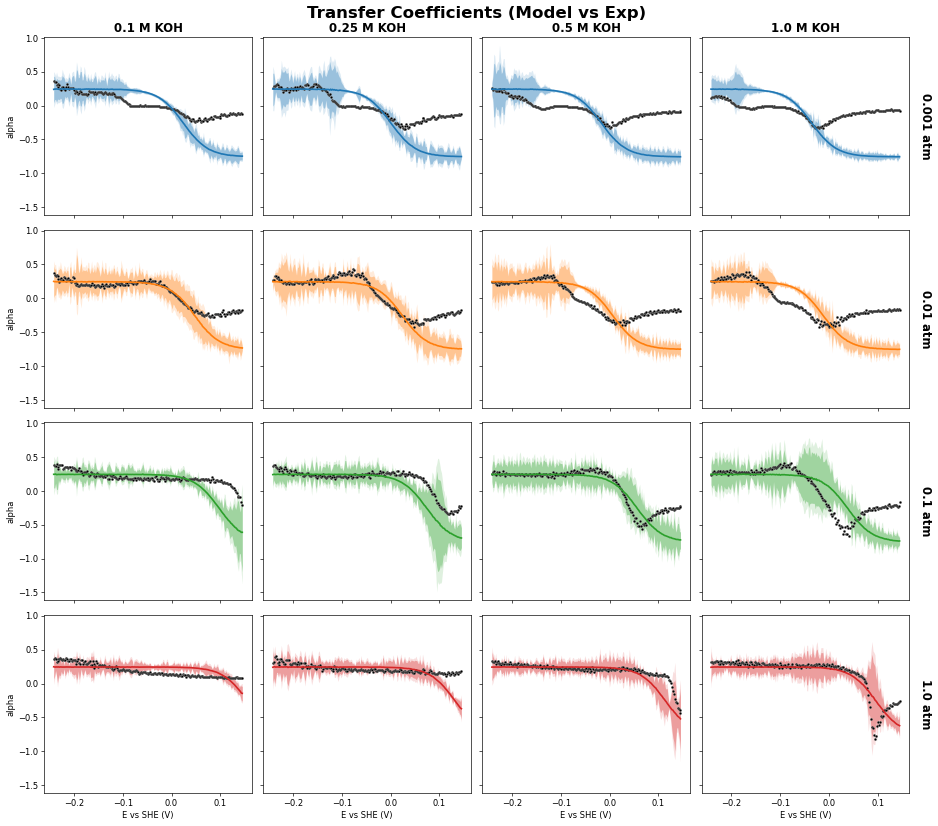

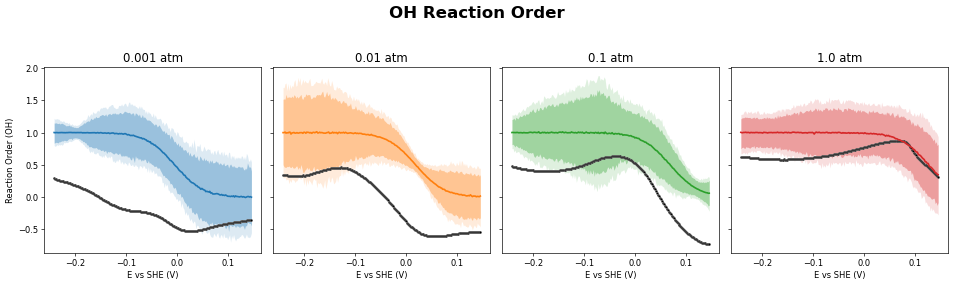

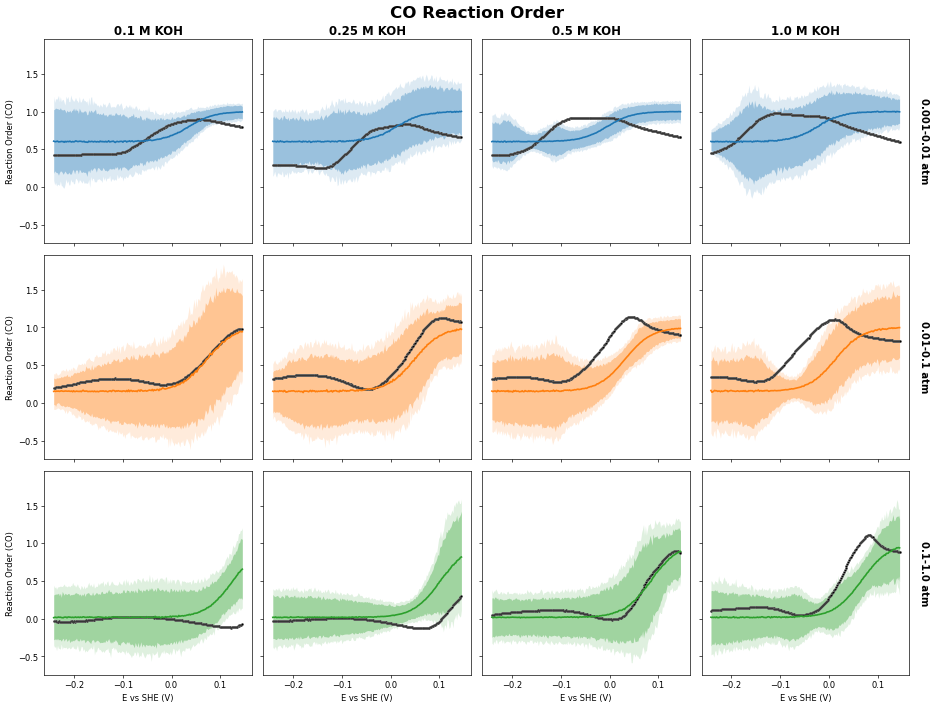

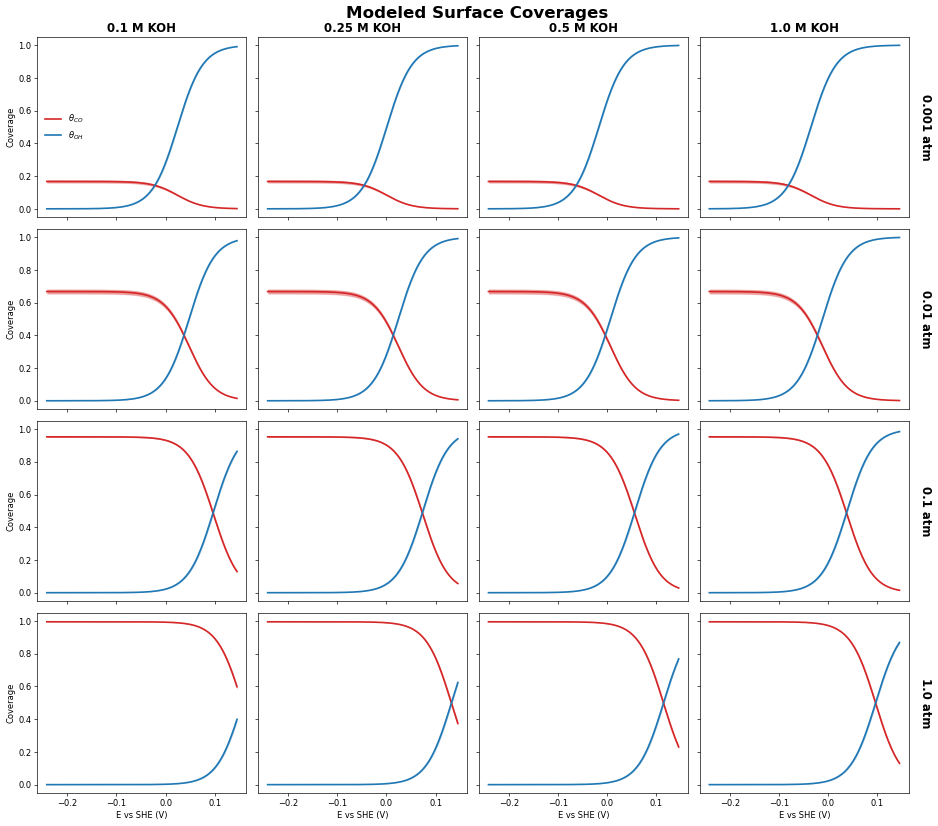

In [12]:
ppc_ER_LH_2 = plot_posteriors(trace_ER_LH_2, ER_LH_2)
plot_model_fits(ppc_ER_LH_2); plot_coverages(trace_ER_LH_2)

# ER 2 + LH 2 + 3 - Series and Parallel RDS

In [13]:
# Helper functions 

def quadratic_solve(a, b, c): 
    max_val = pt.maximum(pt.abs(a), pt.maximum(pt.abs(b), pt.abs(c)))
    a_n = a / max_val; b_n = b / max_val; c_n = c / max_val
    discriminant = pt.sqr(b_n) - 4 * a_n *c_n
    sqrt_disc = pt.sqrt(discriminant)
    root_pos = -2 * c_n / (b_n + sqrt_disc)
    root_neg = (sqrt_disc - b_n) / (2 * a_n)
    return pt.switch(pt.gt(b_n, 0), root_pos, root_neg)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.03,127
,2000,0,0.03,1023
,2000,0,0.04,255
,2000,0,0.03,127


Computed from 4000 posterior samples and 6400 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -213.22   140.75
p_loo      833.33        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     6400  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



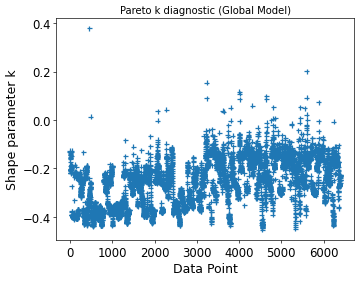

In [14]:
# Eley-Rideal + Langmuir-Hinshelwood Hybrid Model - 2nd and 3rd steps are RDS
with pm.Model() as ER_LH_2_3:
    '''
    1. CO + * -> CO* 
    2a. CO* + OH- -> COOH* + (e-) (RDS) (Reversible)
    2b. CO* + OH* -> COOH* + * (RDS) (Reversible)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (RDS)
    4. OH- + * -> OH* + (e-)
    '''
    # Priors
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-0.5, upper=0.1) 
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-0.4, upper=0.2) # at 0V_SHE
    deltaG2_LH_0 = pm.Normal('deltaG2_LH_0', mu=0, sigma=0.5) # at 0V_SHE
    deltaG2_ER_0 = deltaG2_LH_0 + deltaG4_0 # Hess' law
    beta_2 = pm.Uniform("beta_2", lower=0.05, upper=0.95)
    beta_3 = pm.Uniform("beta_3", lower=0.05, upper=0.95)
    Gact2_LH_0 = 0 # Fixed at 0 eV
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0, sigma=0.5) # at 0V_SHE
    Gact3_0 = pm.Normal('Gact3_0', mu=0, sigma=0.5) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG2_ER = deltaG2_ER_0 - E_in
    deltaG2_LH = deltaG2_LH_0
    deltaG4 = deltaG4_0 - E_in
    Gact2_LH = Gact2_LH_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact3 = Gact3_0 - beta_3*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K2_LH = -deltaG2_LH/(kb_eV*T)
    log_K2_ER = -deltaG2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)

    log_C_KOH = np.log(C_KOH_in)
    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + log_C_KOH

    zeros = pt.zeros_like(term_CO+term_OH)
    log_Z = pt.logsumexp(pt.stack([zeros, term_CO+zeros, term_OH+zeros]), axis=0); Z_term = pt.exp(log_Z)
    log_k2a_fwd = log_k2_ER + log_C_KOH; log_k2b_fwd = log_k2_LH
    log_k2a_rev = log_k2_ER - log_K2_ER; log_k2b_rev = log_k2_LH - log_K2_LH
    log_k3_fwd  = log_k3 + log_C_KOH
    log_R_sink = pt.logaddexp(log_k2a_rev, log_k3_fwd); R_sink = pt.exp(log_R_sink)
    log_a_quad = pt.logaddexp(log_k2b_fwd + term_CO + term_OH, log_Z + log_k2b_rev); a_quad = pt.exp(log_a_quad)
    b_quad = pt.exp(log_k2a_fwd + term_CO) + pt.exp(log_Z + log_R_sink) - pt.exp(log_k2b_rev)
    c_quad = -R_sink
    theta = quadratic_solve(a_quad, b_quad, c_quad)
    num_COOH = pt.exp(log_k2a_fwd + term_CO) * theta + pt.exp(log_k2b_fwd + term_CO + term_OH) * pt.sqr(theta)
    den_COOH = R_sink + pt.exp(log_k2b_rev) * theta
    theta_COOH = num_COOH / den_COOH

    theta_CO = pm.Deterministic('theta_CO', pt.exp(term_CO) * theta)
    theta_OH = pm.Deterministic('theta_OH', pt.exp(term_OH) * theta)

    log_rate = log_k3 + pt.log(theta_COOH) + log_C_KOH
    alpha, delta_OH, delta_CO = observables(log_rate)
        
trace_ER_LH_2_3, loo_ER_LH_2_3 = fit_and_evaluate(ER_LH_2_3)

Kinetic Parameters found: ['deltaG2_LH_0', 'Gact2_ER_0', 'Gact3_0', 'deltaG1_0', 'deltaG4_0', 'beta_2', 'beta_3']
               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG2_LH_0 -0.389  0.342  -0.946    0.066      0.125    0.020       7.0      41.0   1.53
Gact2_ER_0   -0.515  0.201  -0.852   -0.208      0.017    0.020     102.0      36.0   1.09
Gact3_0      -0.318  0.211  -0.659    0.040      0.033    0.020      25.0      36.0   1.17
deltaG1_0    -0.146  0.022  -0.192   -0.127      0.011    0.006       7.0      38.0   1.53
deltaG4_0    -0.288  0.052  -0.386   -0.253      0.026    0.015       7.0      40.0   1.53
beta_2        0.824  0.020   0.787    0.841      0.010    0.006       7.0      28.0   1.53
beta_3        0.238  0.007   0.230    0.252      0.004    0.002       7.0      30.0   1.53


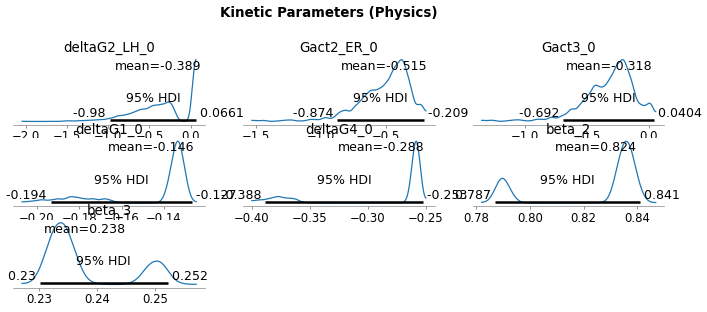

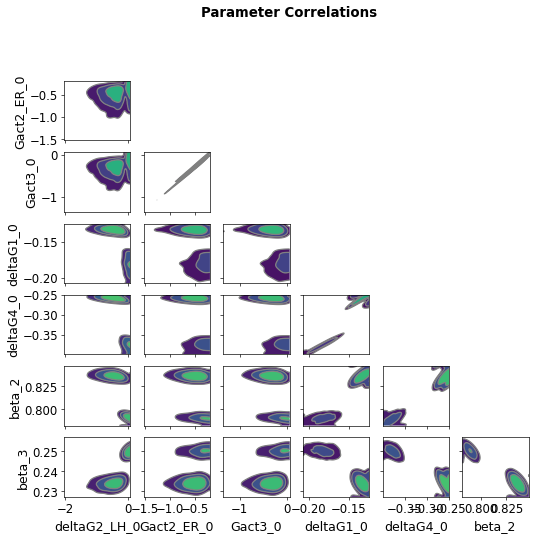

Sampling: [alpha, delta_CO, delta_OH]


alpha: 0.585
delta_OH: 0.649
delta_CO: 0.663


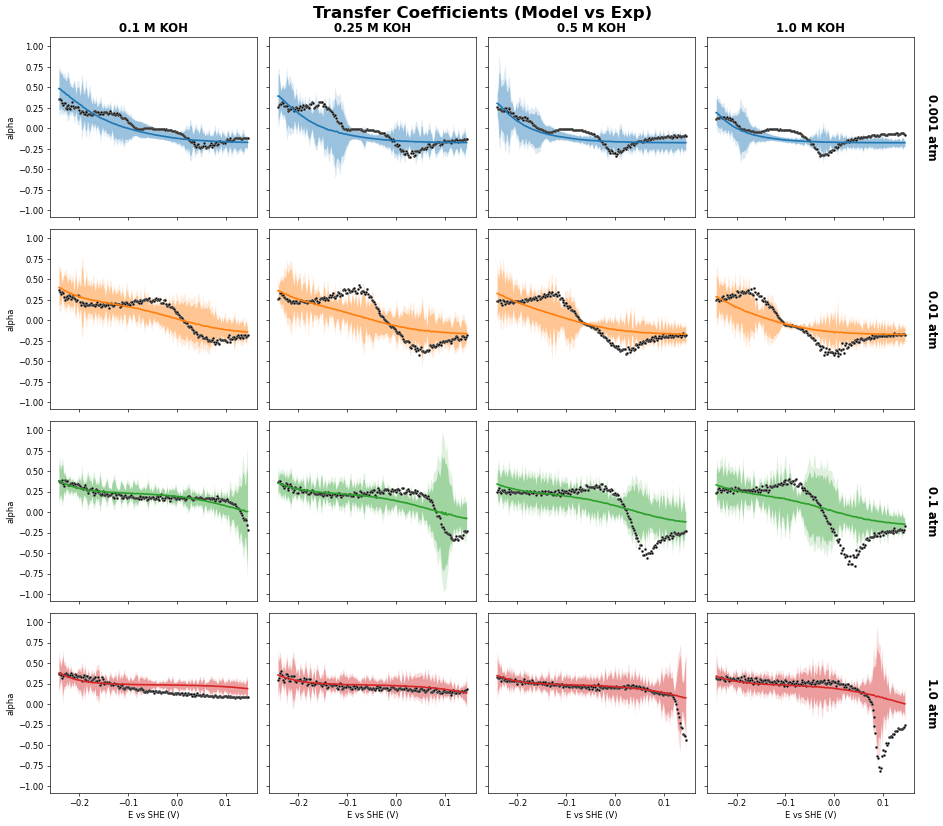

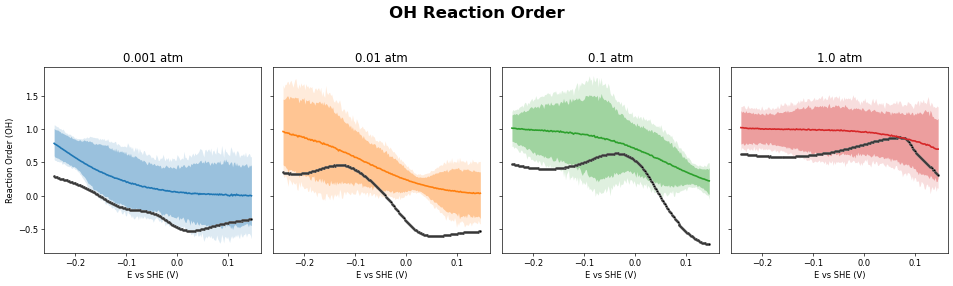

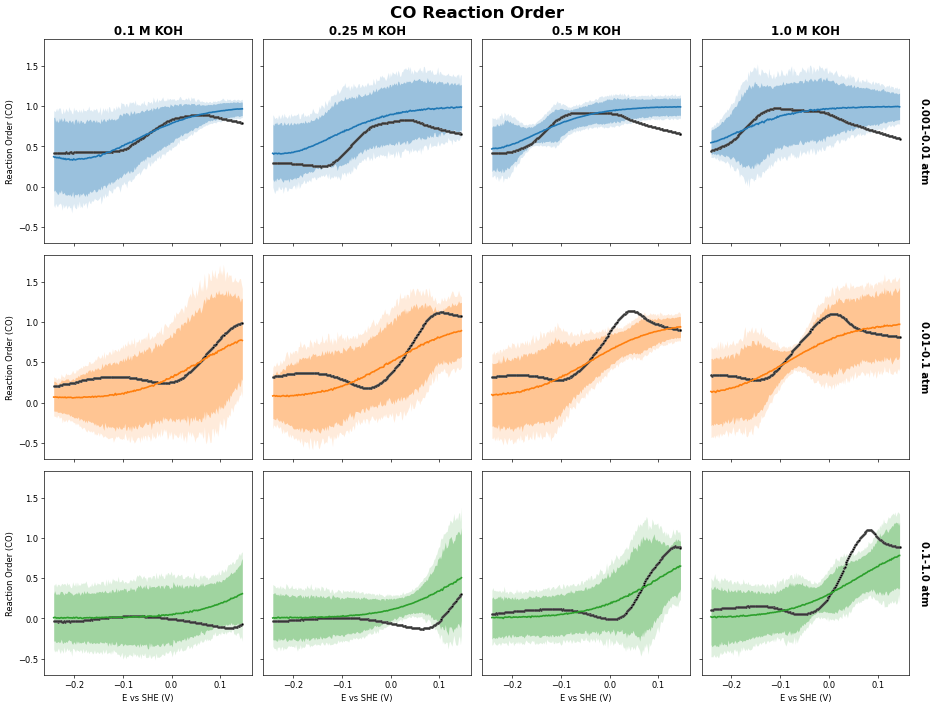

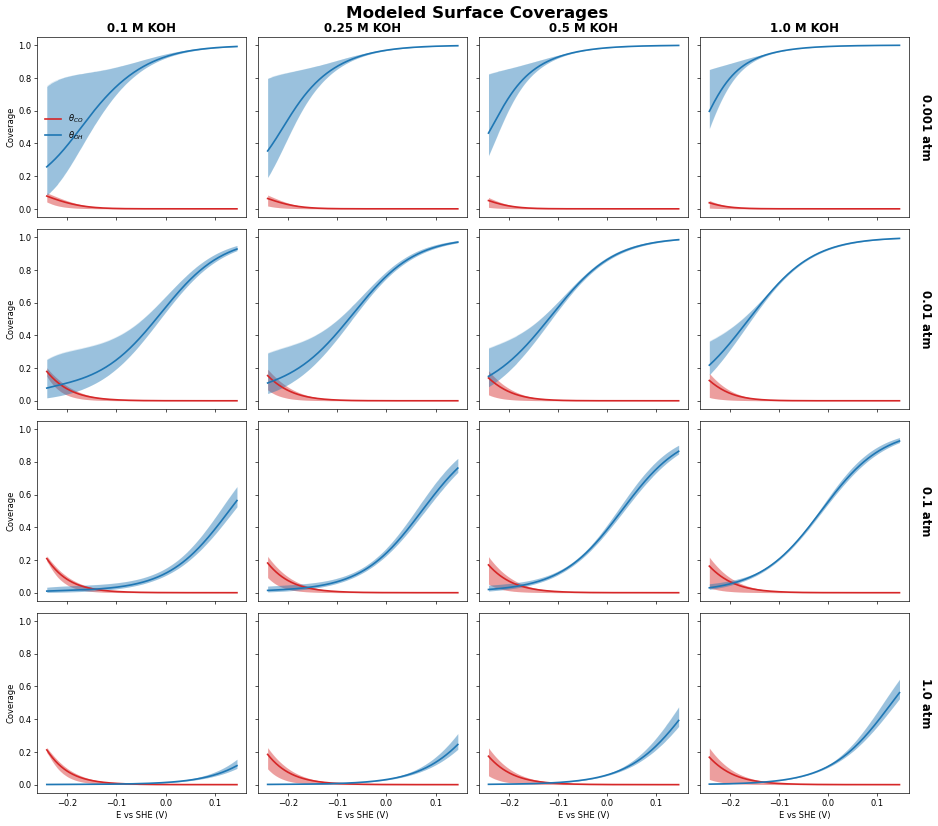

In [15]:
ppc_ER_LH_2_3 = plot_posteriors(trace_ER_LH_2_3, ER_LH_2_3)
plot_model_fits(ppc_ER_LH_2_3); plot_coverages(trace_ER_LH_2_3)

# Comparison

           rank     elpd_loo        p_loo    elpd_diff    weight          se         dse  warning scale
ER_LH_2_3     0  -213.220614   833.327490     0.000000  0.815178  140.747969    0.000000    False   log
ER_2_3        1 -2996.973450  3728.341496  2783.752836  0.000002  164.885305   86.350387    False   log
ER_2          2 -5573.733718    18.707814  5360.513104  0.184822  214.687124  190.072756    False   log
ER_LH_2       3 -5573.761411    18.694484  5360.540797  0.000000  214.690829  190.067344    False   log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

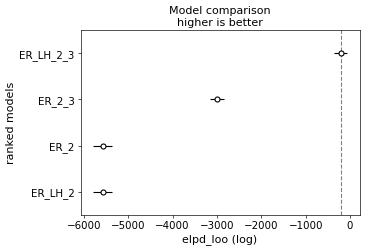

In [16]:

comparison_dict = {
    "ER_2": loo_ER_2, 
    # "LH_2": loo_LH_2, 
    # "ER_3": loo_ER_3, 
    # "LH_3": loo_LH_3, 
    "ER_2_3": loo_ER_2_3,  
    "ER_LH_2": loo_ER_LH_2, 
    "ER_LH_2_3": loo_ER_LH_2_3,

}
comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)